In [1]:
#Inference Evaluation Script
from Single_ag_Environment import SingleSatelliteEnv#Import the environment
from gymnasium.utils.env_checker import check_env#Import check environment functionality
import traceback
import numpy as np
import gymnasium as gym
import torch
print(type(SingleSatelliteEnv))
# This will catch many common issues
env = SingleSatelliteEnv(render_mode="None")
try:
    check_env(env)
    print("Environment passes all checks!")
except Exception as e:
    print("Environment has issues:")
    traceback.print_exc()
from cleanrl.cleanrl.dqn import QNetwork#Import Q network from DQN script
from cleanrl.cleanrl.c51 import QNetwork as C51Network#Import Q network from C51 script
from cleanrl.cleanrl.ppo import Agent#Import Agent from PPO script
env =SingleSatelliteEnv(render_mode="None")
envs = gym.vector.SyncVectorEnv([
    lambda: SingleSatelliteEnv(render_mode="None")#Setup vectorized environment (might not be necessary)
])


<class 'type'>
Environment passes all checks!


/home/ethan/Documents/Research/Single_Agent_EO_Project/CleanAgvenv/lib/python3.10/site-packages/gymnasium/utils/env_checker.py:321: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantialising the environment through gymnasium.make
  logger.warn(
/home/ethan/Documents/Research/Single_Agent_EO_Project/CleanAgvenv/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment SingleSatelliteEnv already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [2]:
#C51
#The initial template for running the algorithms was developed with ChatGPT, we then modified it to suit our needs
def C51_test(Testing_seed_Configuration,num_of_models):
    envs = gym.vector.SyncVectorEnv([
        lambda: SingleSatelliteEnv(render_mode="None")
    ])#vectorize environment
    #Put the output vectors here for the tests
    vector_index=0#index for the different metric vectors
    C51_reward_vector=np.zeros([len(Testing_seed_Configuration)*num_of_models,])#Reward vector initialization
    C51_delivery_ratio_vector=np.zeros([len(Testing_seed_Configuration)*num_of_models,])#Delivery Ratio vector initialization
    C51_mean_contact_energy_efficiency_vector=np.zeros([len(Testing_seed_Configuration)*num_of_models,])#Mean Contact Energy Efficiency vector initialization
    C51_initial_data_volume=np.zeros([len(Testing_seed_Configuration)*num_of_models,])#Initial Data volume vector initialization
    
    for i in range(0,len(Testing_seed_Configuration)):
            
            for k in range(0,num_of_models):
                init_obs,init_info=envs.reset(seed=Testing_seed_Configuration[i])
                
                model = C51Network(envs).to("cpu")
                
                # Load trained weights
                checkpoint = torch.load("Models/C51/c51_"+str(k)+".cleanrl_model")#We retrieve the checkpoint file
                model.load_state_dict(checkpoint["model_weights"]) #We get the model weights
                obs=init_obs.copy()#We use copy to be safe
                done = False
                total_reward=0
                while not done:
                    obs_tensor = torch.tensor(obs, dtype=torch.float32)#We get the tensor from the observation space
                    with torch.no_grad():
                        action, q_values = model.get_action(obs_tensor)#We input the tensor in the get_action function to get the action from the model
                        action=int(action)#Convert the action to an int
                    obs, reward, terminated, truncated, info = envs.step([action])#Get next obs, reward...
                    total_reward+=reward#We add to the total reward
                    done = terminated or truncated#Check if the episode is over
                
                final_info=info['final_info'][0]#Get the final info 
                #print(final_info)
                initial_data_volume=final_info['Initial Data']#Get initial data that we needed to send
                #print("c51 initial data")
                #print(initial_data_volume)
                delivered_packets=final_info['Delivered Data']#Get the number of packets delivered during the episode
                #print("c51 delivered_packets")
                #print(delivered_packets)
                number_of_contacts=final_info['Number of Contacts']#Get the number of contacts that were usedi n hte episode
                excess_energy_expended=final_info['Energy Expended']#Get the energy expended 
                C51_reward_vector[vector_index]=total_reward#Update the reward vector with the total reward for this model and seed
                C51_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)#We calculate delivery ratio by dividing the number of delivered packets by the packets 
                if number_of_contacts>0:
                    C51_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/(number_of_contacts*10)#Calculate the mean energy efficiency
                else:
                    C51_mean_contact_energy_efficiency_vector[vector_index]=0#We set the energy efficiency to zero if we don't use any contacts
                C51_initial_data_volume[vector_index]=initial_data_volume*100#add to the initial data volume vector
                vector_index+=1#Increment index
    envs.close()
    return C51_reward_vector,C51_delivery_ratio_vector,C51_mean_contact_energy_efficiency_vector,C51_initial_data_volume#Output metrics
            


In [3]:
#DQN
#We used the C51 template and modified it
def DQN_test(Testing_seed_Configuration,num_of_test_episodes,num_of_models):
    envs = gym.vector.SyncVectorEnv([
        lambda: SingleSatelliteEnv(render_mode="None")
    ])#Convert to vectorized environment (not sure if this is necessary
    DQN_reward_vector=np.zeros([len(Testing_seed_Configuration)*num_of_models,])#Setup the metric outputs
    DQN_delivery_ratio_vector=np.zeros([len(Testing_seed_Configuration)*num_of_models,])#Setup metric output
    DQN_mean_contact_energy_efficiency_vector=np.zeros([len(Testing_seed_Configuration)*num_of_models,])#Setup metric output
    DQN_initial_data_volume=np.zeros([len(Testing_seed_Configuration)*num_of_models,])#Setup metric output
    vector_index=0#Initialize vector index
    for i in range(0,len(Testing_seed_Configuration)):#There was a mistake here that we fixed after the presentation was completed
            for k in range(0,num_of_models):#Test all the models
                obs_init,init_info=envs.reset(seed=Testing_seed_Configuration[i])#Set the seed for the experiment
                model = QNetwork(envs).to("cpu")#Get the Q Network from the model
                checkpoint = torch.load("Models/DQN/dqn_"+str(k)+".cleanrl_model")#Load the specific checkpoint
                model.load_state_dict(checkpoint)#Get the model
                obs=obs_init.copy()#Copy to be safe
                done = False
                total_reward=0
                while not done:
                    obs_tensor = torch.tensor(obs, dtype=torch.float32)#Get tensor 
                    with torch.no_grad():
                        q_values = model(torch.Tensor(obs).to("cpu"))#get the qvalues by inputting the tensor into the model
                        action= torch.argmax(q_values, dim=1).cpu().numpy()#get the action by taking getting the argmax of the qvalues
                    obs, reward, terminated, truncated, info = envs.step(action)#Take action and get next obs, reward and termination conditions
                    total_reward+=reward#update total reward
                    done = terminated or truncated#Check if the episode is over
                final_info=info['final_info'][0]#Get data from final step
                initial_data_volume=final_info["Initial Data"]#Get the initial data
                delivered_packets=final_info["Delivered Data"]#Get the number of delivered packets
                number_of_contacts=final_info["Number of Contacts"]#Get the number of contacts used
                excess_energy_expended=final_info["Energy Expended"]#Get the energy expended over the entire episode
                DQN_reward_vector[vector_index]=total_reward#note total reward
                DQN_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)#Delivery Ratio is the number of delivered packets divided by the intial data volume
                if number_of_contacts>0:
                    DQN_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/(number_of_contacts*10)#Calculate energy efficiency
                else:
                    DQN_mean_contact_energy_efficiency_vector[vector_index]=0
                DQN_initial_data_volume[vector_index]=initial_data_volume*100
                vector_index+=1
    envs.close()
    return DQN_reward_vector,DQN_delivery_ratio_vector,DQN_mean_contact_energy_efficiency_vector,DQN_initial_data_volume
            

In [4]:
#PPO
# Load environment
#Initial format was created with ChatGPT and then modified 
def PPO_test(Testing_seed_Configuration,num_of_test_episodes,num_of_models):
    envs = gym.vector.SyncVectorEnv([
        lambda: SingleSatelliteEnv(render_mode="None")
    ])#Convert to vectorized environment
   
    PPO_reward_vector=np.zeros([len(Testing_seed_Configuration)*num_of_models,])#Initializing main variables to collect metrics
    PPO_delivery_ratio_vector=np.zeros([len(Testing_seed_Configuration)*num_of_models,])
    PPO_mean_contact_energy_efficiency_vector=np.zeros([len(Testing_seed_Configuration)*num_of_models,])
    PPO_initial_data_volume=np.zeros([len(Testing_seed_Configuration)*num_of_models,])
    vector_index=0
    for i in range(0,len(Testing_seed_Configuration)):
            for k in range(0,num_of_models):
                obs_init,init_info=envs.reset(seed=Testing_seed_Configuration[i])#Reset environment according to predefined seed
                agent = Agent(envs).to("cpu")#Get the agent (policy)
                checkpoint = torch.load("Models/PPO/ppo_"+str(k)+".cleanrl_model")#Import the checkpoint that we saved
                agent.load_state_dict(checkpoint["model"])#Get the agent from the checkpoint
                obs = obs_init.copy()#Copy obs to be safe
                done = False
                total_reward=0
                while not done:
                    obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)#Make obs a tensor)
                    with torch.no_grad():
                        action, _, _,qvalue = agent.get_action_and_value(obs_tensor)#Get the action using the action_value function
                    obs, reward, terminated, truncated, info = envs.step(action)
                    total_reward+=reward
                    done = terminated or truncated
                final_info=info['final_info'][0]#Get metrics from final step of episode
                initial_data_volume=final_info["Initial Data"]
                delivered_packets=final_info["Delivered Data"]
                number_of_contacts=final_info["Number of Contacts"]
                excess_energy_expended=final_info["Energy Expended"]
                PPO_reward_vector[vector_index]=total_reward
                PPO_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
                if number_of_contacts>0:
                    PPO_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/(number_of_contacts*10)
                else:
                    PPO_mean_contact_energy_efficiency_vector[vector_index]=0
                PPO_initial_data_volume[vector_index]=initial_data_volume*100
                vector_index+=1
    envs.close()
    return PPO_reward_vector,PPO_delivery_ratio_vector,PPO_mean_contact_energy_efficiency_vector,PPO_initial_data_volume

In [ ]:
#Baseline ALgorithms
def BaselineCGR(env,obs,init_info):
    delivery_ratio_metric=None#Delivery Ratio Metric
    contact_energy_efficiency=None#Contact Energy Efficiency metric
    total_reward=0
    done=False
    while not done:
        action = 1#We always choose action 1 until the episode is over
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
    #Next we need to extract final info from the episode
    initial_data_volume=info["Initial Data"]
    delivered_packets=info["Delivered Data"]
    number_of_contacts=info["Number of Contacts"]
    excess_energy_expended=info["Energy Expended"]
    return total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended#Return key metrics

In [ ]:
#Adaptive Sorting Algorithm
def AdaptiveSorting(env,init_obs,init_info):
    initial_observation,initial_information=init_obs,init_info
    print(initial_observation)
    initial_data_volume=initial_observation[10]*100
    contacts_available=initial_observation[0:10]
    sorted_matrix=np.zeros([10,2])
    current_contact_iterator=0
    total_reward=0
  
    
    #Next we must calculate the initial allocation of contacts
    j=0
    for i in contacts_available:
        sorted_matrix[j,0]=i
        sorted_matrix[j,1]=j
        j=j+1
    sorted_matrix=sorted_matrix[sorted_matrix[:, 0].argsort()]
    #print("Initial Sorted Matrix")
    #print(sorted_matrix)
    remaining_data=initial_data_volume
    #print("Initial Data to send")
    #print(remaining_data)
    decision_matrix=np.zeros([10,2])
    
    j=0
    for i in range(0,len(decision_matrix)):
        if (remaining_data>0):
            if sorted_matrix[i,0]<1:
                remaining_data=remaining_data-(10-sorted_matrix[i,0]*10)
                
                decision_matrix[i,0]=1
                decision_matrix[i,1]=sorted_matrix[i,1]
            else:
                decision_matrix[i,0]=0
                decision_matrix[i,1]=sorted_matrix[i,1]
        else:
            decision_matrix[i,0]=0
            decision_matrix[i,1]=sorted_matrix[i,1]
    #Next we must reorder the decision matrix
    

    #print("Decision Matrix")
    #print(decision_matrix)
    sorted_decisions=decision_matrix[decision_matrix[:,1].argsort()]
    #print("Sorted Decisions")
    #print(sorted_decisions)
    action_decision_matrix=np.zeros(10)
    for i in range(0,len(sorted_decisions)):
        action_decision_matrix[i]=sorted_decisions[i,0]
    #print("Actual set of Actions")
    #print(action_decision_matrix)
    obs=initial_observation
    i=0
    done=False
    while not done:
        if action_decision_matrix[i]==0:
            #We don't use this contact
            action=0
            next_obs, reward, terminated, truncated, info = env.step(action)
            print("Action")
            print(action)
            total_reward+=reward
        else:
            #We use the contact
            
            action=1
            #print(action)
            next_obs, reward, terminated, truncated, info = env.step(action)
            total_reward+=reward
            #Next we need to determine if we successfully delivered any packets
            current_delivered=1-next_obs[10]
            print("Current_Delivered")
            print(current_delivered)
            previous_delivered=1-obs[10]
            #print(previous_delivered)
            if (current_delivered<previous_delivered):
                #We need to recalculate the decision matrix
                remaining_data=current_delivered*100
                aux_sorting_matrix=np.zeros([10,2])
                for j in range(0,10):
                    aux_sorting_matrix[j,0]=contacts_available[j]
                    aux_sorting_matrix[j,1]=j
                for j in range(0,i+1):
                    aux_sorting_matrix[j,0]=1
                #print("Auxilliary Sorting Matrix")
                #print(aux_sorting_matrix)
                aux_sorting_matrix=aux_sorting_matrix[aux_sorting_matrix[:, 0].argsort()]
                #print("Auxilliary Sorting Matrix")
                #print(aux_sorting_matrix)
                decision_matrix=np.zeros([10,2])
                k=0
                for j in range(0,len(decision_matrix)):
                    if remaining_data>0:
                        if aux_sorting_matrix[j,0]<1:
                            remaining_data=remaining_data-(10-aux_sorting_matrix[j,0]*10)
                            decision_matrix[j,0]=1
                            decision_matrix[j,1]=aux_sorting_matrix[j,1]
                        else:
                            decision_matrix[j,0]=0
                            decision_matrix[j,1]=aux_sorting_matrix[j,1]
                    else:
                        decision_matrix[j,0]=0
                        decision_matrix[j,1]=aux_sorting_matrix[j,1]

                aux_sorting_decisions=decision_matrix[decision_matrix[:,1].argsort()]
                action_decision_matrix=np.zeros(10)
                for k in range(0,len(aux_sorting_decisions)):
                    action_decision_matrix[k]=aux_sorting_decisions[k,0]
                #print("New Decision Matrix")
                #print(action_decision_matrix)
        i+=1
        obs=next_obs
        done = terminated or truncated
    #Next we need to graph and log the results of the heuristic algorithm
    initial_data_volume=info["Initial Data"]
    print("Sorting Algo")
    print("Initial Data Volume")
    print(initial_data_volume)
    delivered_packets=info["Delivered Data"]
    print(delivered_packets)
    number_of_contacts=info["Number of Contacts"]
    excess_energy_expended=info["Energy Expended"]
    if((initial_data_volume*100)<delivered_packets):
        print("Delivery ratio error")
    return total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended
    env.close()


In [7]:
#Evaluation was conducted on 10 independent episodes using 10 seeds
#Each algorithm was tested (with 5 trained models for each DRL algorithm evaluated)
seeds=[50,51,52,53,54,55,56,57,58,59,60]
C51_tr,C51_dr,C51_ec,C51_initial_data_volume=C51_test(seeds,5)
CGR_reward_vector=np.zeros([len(seeds)*5,])
CGR_delivery_ratio_vector=np.zeros([len(seeds)*5,])
CGR_mean_contact_energy_efficiency_vector=np.zeros([len(seeds)*5,])
CGR_initial_data_volume=np.zeros([len(seeds)*5,])
Sort_reward_vector=np.zeros([len(seeds)*5,])
Sort_delivery_ratio_vector=np.zeros([len(seeds)*5,])
Sort_mean_contact_energy_efficiency_vector=np.zeros([len(seeds)*5,])
Sort_initial_data_volume=np.zeros([len(seeds)*5,])
vector_index=0
for b in seeds:
        for k in range(0,5):
            init_obs,init_info=env.reset(seed=b)
            obs=init_obs.copy()
            info=init_info.copy()
            total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=BaselineCGR(env,obs,info)
          
            CGR_reward_vector[vector_index]=total_reward
            CGR_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
            if number_of_contacts>0:
                CGR_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/(number_of_contacts*10)
            else:
                CGR_mean_contact_energy_efficiency_vector[vector_index]=0
            CGR_initial_data_volume[vector_index]=initial_data_volume*100
            vector_index+=1
env.close()
#Next we must make box plots these results


DQN_tr,DQN_dr,DQN_ec,DQN_initial_data_volume=DQN_test(seeds,100,5)
PPO_tr,PPO_dr,PPO_ec,PPO_initial_data_volume=PPO_test(seeds,100,5)


/tmp/ipykernel_95621/2433466824.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("Models/C51/c51_"+str(k)+".cleanrl_model")#We retrieve the check

[0.8 0.8 0.5 1.  0.2 0.6 0.1 0.6 0.4 0.3 0.7 0. ]
[0.8 0.8 0.5 1.  0.2 0.6 0.1 0.6 0.4 0.3 0.7 0. ]
[0.8 0.8 0.5 1.  0.2 0.6 0.1 0.6 0.4 0.3 0.7 0. ]
[0.8 0.8 0.5 1.  0.2 0.6 0.1 0.6 0.4 0.3 0.7 0. ]
[0.8 0.8 0.5 1.  0.2 0.6 0.1 0.6 0.4 0.3 0.7 0. ]
[0.9  0.3  0.3  0.2  0.8  0.2  0.8  0.7  0.4  0.5  0.23 0.  ]
[0.9  0.3  0.3  0.2  0.8  0.2  0.8  0.7  0.4  0.5  0.23 0.  ]
[0.9  0.3  0.3  0.2  0.8  0.2  0.8  0.7  0.4  0.5  0.23 0.  ]
[0.9  0.3  0.3  0.2  0.8  0.2  0.8  0.7  0.4  0.5  0.23 0.  ]
[0.9  0.3  0.3  0.2  0.8  0.2  0.8  0.7  0.4  0.5  0.23 0.  ]
[0.6  0.6  0.5  0.   0.6  1.   0.4  0.   0.2  0.9  0.56 0.  ]
[0.6  0.6  0.5  0.   0.6  1.   0.4  0.   0.2  0.9  0.56 0.  ]
[0.6  0.6  0.5  0.   0.6  1.   0.4  0.   0.2  0.9  0.56 0.  ]
[0.6  0.6  0.5  0.   0.6  1.   0.4  0.   0.2  0.9  0.56 0.  ]
[0.6  0.6  0.5  0.   0.6  1.   0.4  0.   0.2  0.9  0.56 0.  ]
[0.   0.7  0.3  0.9  0.1  0.7  0.8  0.7  1.   0.8  0.67 0.  ]
[0.   0.7  0.3  0.9  0.1  0.7  0.8  0.7  1.   0.8  0.67 0.  ]
[0.   

/tmp/ipykernel_95621/300448797.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("Models/DQN/dqn_"+str(k)+".cleanrl_model")
/tmp/ipykernel_95621/4

[  0.56152136   0.56152136   0.56152136   0.56152136   0.56152136
  -6.07069858  -6.07069858  -6.07069858  -6.07069858  -6.07069858
   2.62604373   2.62604373   2.62604373   2.62604373   2.62604373
   1.48584737   1.48584737   1.48584737   1.48584737   1.48584737
 -59.9895602  -59.9895602  -59.9895602  -59.9895602  -59.9895602
  13.59193759  13.59193759  13.59193759  13.59193759  13.59193759
  16.33391613  16.33391613  16.33391613  16.33391613  16.33391613
  16.03756633  16.03756633  16.03756633  16.03756633  16.03756633
   5.86353245   5.86353245   5.86353245   5.86353245   5.86353245
   4.98544145   4.98544145   4.98544145   4.98544145   4.98544145
  -2.04629842  -2.04629842  -2.04629842  -2.04629842  -2.04629842]
[  1.66018967   0.56152136   0.56152136  -0.18309404   0.56152136
  -6.07069858  -6.07069858  -6.07069858  -6.07069858  -6.07069858
   2.62604373   2.62604373   2.62604373   2.62604373   2.62604373
   2.29213542   2.7059137    2.87075616   2.87075616   2.7059137
 -59.989560

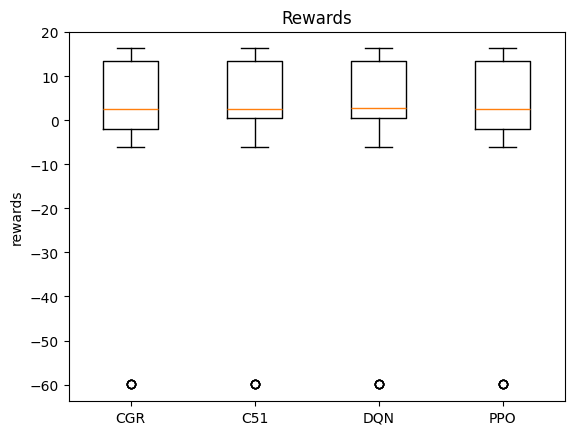

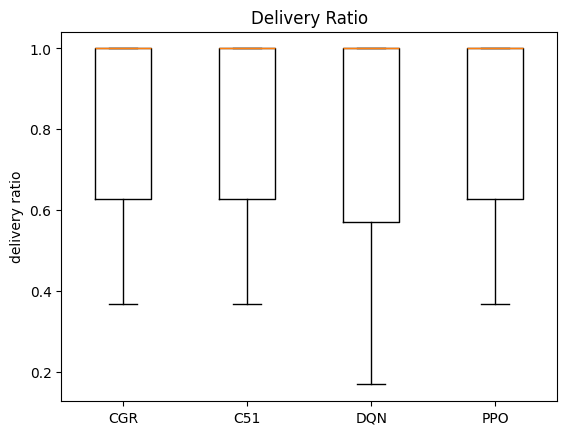

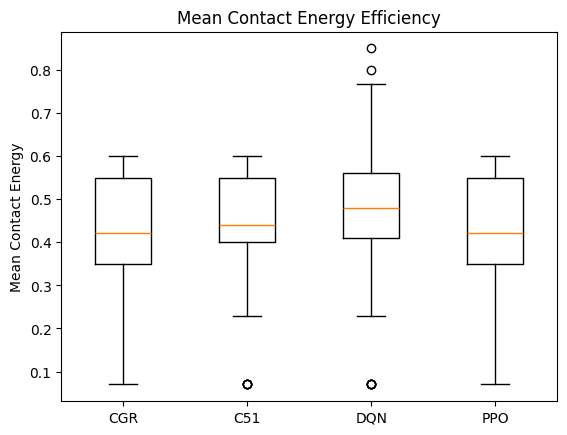

0
0
0


In [8]:
#We produced box and whisker plots for Reward,Delivery Ratio and Mean Contact Energy efficiency metrics
import matplotlib.pyplot as plt
print(PPO_tr)
print(DQN_tr)
print(C51_tr)
print(C51_dr)

plt.boxplot([CGR_reward_vector,C51_tr,DQN_tr,PPO_tr,Sort_reward_vector], tick_labels=['CGR','C51','DQN', 'PPO','Sorting Algorithm'])
plt.title("Rewards")
plt.ylabel("rewards")
plt.savefig("single_agent_reward.png")  
plt.show()
plt.close()
#Delivery Ratio Plot
plt.boxplot([CGR_delivery_ratio_vector, C51_dr,DQN_dr,PPO_dr,Sort_delivery_ratio_vector], tick_labels=['CGR', 'C51','DQN','PPO','Sorting Algorithm'])

plt.title("Delivery Ratio")
plt.ylabel("delivery ratio")
plt.savefig("single_agent_delivery.png") 
plt.show()
plt.close()
#Contact Energy Efficiency Plot
plt.boxplot([CGR_mean_contact_energy_efficiency_vector, C51_ec,DQN_ec,PPO_ec,Sort_mean_contact_energy_efficiency], tick_labels=['CGR', 'C51','DQN','PPO','Sorting Algorithm'])

plt.title("Mean Contact Energy Efficiency")
plt.ylabel("Mean Contact Energy")
plt.savefig("single_agent_energy_efficiency.png") 
plt.show()
plt.close()


#Just some testing code to make sure everything is working properly
num_of_difference=0
for i in range(0,len(CGR_initial_data_volume)):
    if CGR_initial_data_volume[i]!=C51_initial_data_volume[i]:
        num_of_difference+=1
print(num_of_difference)

num_of_difference=0
for i in range(0,len(DQN_initial_data_volume)):
    if DQN_initial_data_volume[i]!=C51_initial_data_volume[i]:
        #print("DQN")
        #print(DQN_initial_data_volume[i])
        #print("C51")
        #print(C51_initial_data_volume[i])
        num_of_difference+=1
print(num_of_difference)
num_of_difference=0
for i in range(0,len(PPO_initial_data_volume)):
    if PPO_initial_data_volume[i]!=C51_initial_data_volume[i]:
        print("PPO")
        print(PPO_initial_data_volume[i])
        print("C51")
        print(C51_initial_data_volume[i])
        num_of_difference+=1
print(num_of_difference)